In [1]:
import numpy as np
import pandas as pd 
import scipy.integrate as integrate
import matplotlib.pyplot as plt
import scipy 

### $$ f(x; \nu) = \frac{1}{2^{\nu/2}\Gamma(\nu/2)} x^{\nu/2 - 1}e^{-x/2}, \; x> 0$$

In [2]:
def chi2 (x, nu):
    return 1.0/(2.0**(nu*0.5)*scipy.special.gamma(nu*0.5))*x**(nu*0.5 - 1.0)*np.exp(-x*0.5)

def var_muestral(x_array, x_mean):
    sum = 0
    for element in x_array:
        sum += (element - x_mean)**2
    return sum/(np.size(x_array) - 1.0)

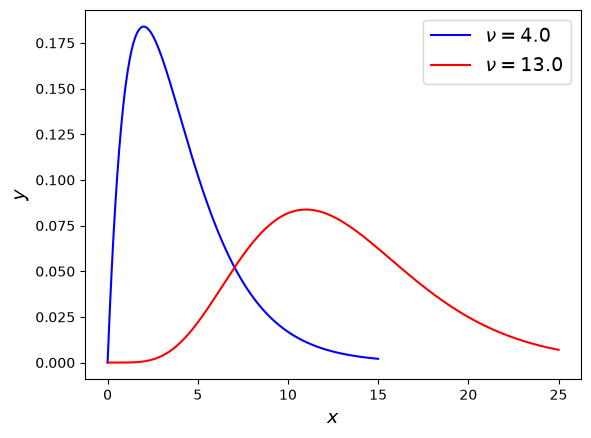

In [3]:
nu = 4
x_array = np.linspace(0.000001, 15.0, 1000)
y_array = chi2 (x_array, nu)

plt.plot(x_array, y_array, linestyle = '-', color= 'blue', label = r'$\nu = %.1f$' %nu)

nu = 13
x_array = np.linspace(0.000001, 25.0, 1000)
y_array = chi2(x_array, nu)

plt.plot(x_array, y_array, linestyle= '-', color='red', label = r'$\nu = %.1f$' %nu)

plt.xlabel(r'$x$', fontsize = 14)
plt.ylabel(r'$y$', fontsize =14)
plt.legend(fontsize = 14)
plt.show()


### Chequeo de normalizacion
$$
\int_0^\infty f(x; \nu) dx = 1
$$

In [4]:
nu = 4 
integral = integrate.quad(chi2, 0.000001, np.inf, args = (nu))
print('nu = %.1f, normalizacion = '%nu, integral[0])

nu = 4.0, normalizacion =  0.999999999999875


## Problema de baterias
- Ejemplo: Un fabricante de bateriasnpara automoviles garantizan que sus baterias duraran, en promedio 3 anos con una desviacion estandar de 1 ano. Si 5 baterias tienen duraciones de 1.9, 2.4, 3.0, 3.5 y 4.2 anos. El fabricante esta seguro de que sus baterias tienen una desviacion estandar de un ano ? Suponga la distribucion de las baterias sigue una distribucion normal.

- Datos: m=3 ; sigma=1 ; n=5, v= n-1 = 4

- calcula s^2

In [5]:
n = 5; nu = n-1
x_datos = np.asarray([1.9, 2.4, 3.0, 3.5, 4.2])
x_mean = np.mean(x_datos)
S2 = var_muestral(x_datos, x_mean)
print("La varianza muestral es =", S2)

La varianza muestral es = 0.8150000000000002


In [6]:
np.var (x_datos, ddof=1)

np.float64(0.8150000000000002)

$$
\chi^2 = \frac{(n-1)S^2}{\sigma^2},
$$

In [7]:
sigma2 = 1.0
chi2 = (nu * S2) / sigma2
print(chi2)

3.2600000000000007


la meida de la poblacion del fabricante es

$$
\mu = \nu = 4
$$

y la desviacion estandar de la poblacion es
$$
\sigma = \sqrt{2\nu} = \sqrt{8} \approx 2.82
$$

Un resultado razonable seria si el estadistico $S^2$ esta "cercano" a la media de la varianza poblacional, esto es si
$$
\chi^2 = 3.26 \in [\mu - \sigma, \mu + \sigma] = [2.82, 6.82]
$$

Entonces, como $\chi^2$ se encuentra dentro de una $\sigma$ de distancia, podemos concluir que la varianza poblacional de un año de duracion de baterias es razonables

In [7]:
sigma2 = 1.0
chi2 = (nu * S2) / sigma2
print(chi2)

3.2600000000000007
